In [1]:
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
dataset_path = r"D:\archive\data"

print(os.listdir(dataset_path)[0:])

['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
classes = os.listdir(dataset_path)

print("Number of Classes:", len(classes))
print(classes)

Number of Classes: 35
['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


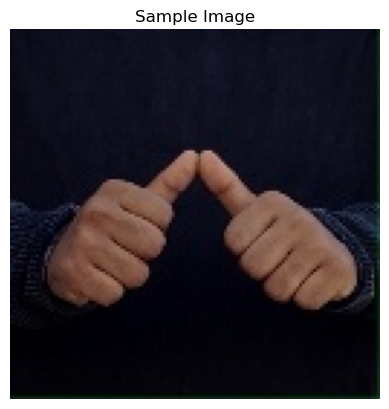

In [4]:
import cv2

sample_path = os.path.join(dataset_path, "A")
sample_image = os.listdir(sample_path)[0]

img = cv2.imread(
    os.path.join(sample_path, sample_image)
)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")
plt.show()

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [6]:
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 33600 images belonging to 35 classes.


In [7]:
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 8400 images belonging to 35 classes.


In [8]:
print("Classes:", train_generator.num_classes)
print(train_generator.class_indices)

Classes: 35
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'O': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}


In [9]:
print(train_generator.class_indices)

{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'O': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential([
    Input(shape=(64,64,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(35, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 35)                  │           8,995 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,282,147 (4.89 MB)

 Trainable params: 1,282,147 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 705s 668ms/step - accuracy: 0.9715 - loss: 0.1080 - val_accuracy: 0.9929 - val_loss: 0.0435
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 372s 354ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.9956 - val_loss: 0.0177
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 110s 105ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9955 - val_loss: 0.0270
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 117s 111ms/step - accuracy: 0.9993 - loss: 0.0023 - val_accuracy: 0.9919 - val_loss: 0.0348
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 132s 126ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.9944 - val_loss: 0.0420


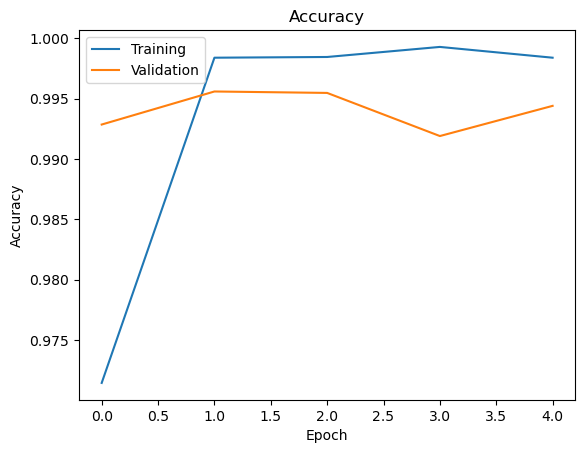

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

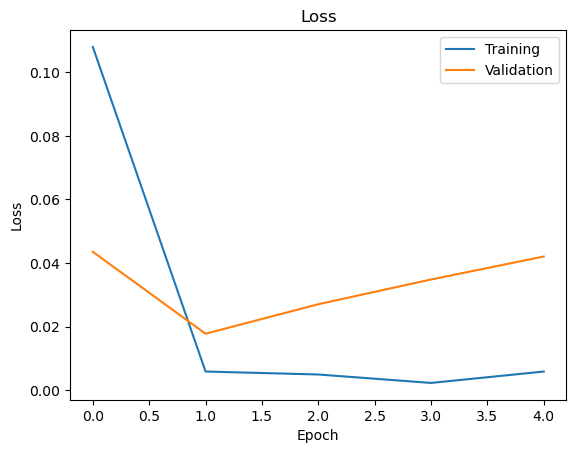

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

In [17]:
loss, accuracy = model.evaluate(
    validation_generator
)

print("Accuracy:", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9944 - loss: 0.0420
Accuracy: 0.9944047331809998


In [18]:
model.save("sign_language_model.keras")

In [19]:
import os

print(os.path.exists("test.jpg"))

False


In [20]:
img = cv2.imread(r"D:\archive\test.jpg")

In [21]:
img = cv2.imread(r"D:\path\to\your\image.jpg")

print(img is None)

True


In [22]:
import os

folder = r"D:\archive\data\2"

print(os.listdir(folder)[:10])

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg']


In [23]:
img = cv2.imread(r"D:\archive\data\2\1000.jpg")

print(img is None)

False


In [24]:
import os

image_path = r"D:\archive\data\2\2_1.jpg"

print(os.path.exists(image_path))

False


In [25]:
import os

folder = r"D:\archive\data\2"

files = os.listdir(folder)

print(files[:20])

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg', '1006.jpg', '1007.jpg', '1008.jpg', '1009.jpg', '101.jpg', '1010.jpg', '1011.jpg', '1012.jpg', '1013.jpg', '1014.jpg']


Files found:
['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg']
Using: D:\archive\data\2\0.jpg
Image loaded: True


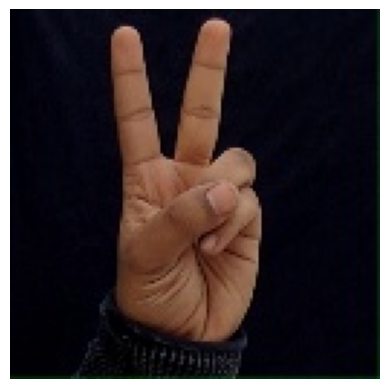

In [26]:
import os
import cv2
import matplotlib.pyplot as plt

folder = r"D:\archive\data\2"

files = os.listdir(folder)

print("Files found:")
print(files[:10])

image_path = os.path.join(folder, files[0])

print("Using:", image_path)

img = cv2.imread(image_path)

print("Image loaded:", img is not None)

if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [27]:
import cv2
import numpy as np

image_path = r"D:\archive\data\2\0.jpg"

img = cv2.imread(image_path)

img = cv2.resize(img, (64,64))

img = img / 255.0

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
[[2.3313902e-18 1.0000000e+00 3.8436155e-21 1.9668505e-23 1.2402201e-25
  8.6421128e-22 1.9519546e-22 7.6678252e-23 2.4818412e-22 2.2633031e-24
  1.7825215e-24 6.2911503e-26 2.9445900e-26 6.2139597e-21 4.5098468e-24
  6.0478681e-22 7.3195463e-28 8.4263632e-18 1.0777841e-27 6.9640215e-24
  4.8154392e-22 4.9453233e-22 6.0615960e-27 2.1216991e-21 1.1014821e-23
  3.0497776e-26 1.4710452e-26 1.3632372e-19 1.3391203e-27 1.2171157e-22
  8.6577484e-23 2.2415254e-21 8.5405823e-22 7.6896199e-30 2.1410088e-21]]


In [28]:
class_names = list(train_generator.class_indices.keys())

predicted_class = np.argmax(prediction)

print("Predicted Class:",
      class_names[predicted_class])

Predicted Class: 2


263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step


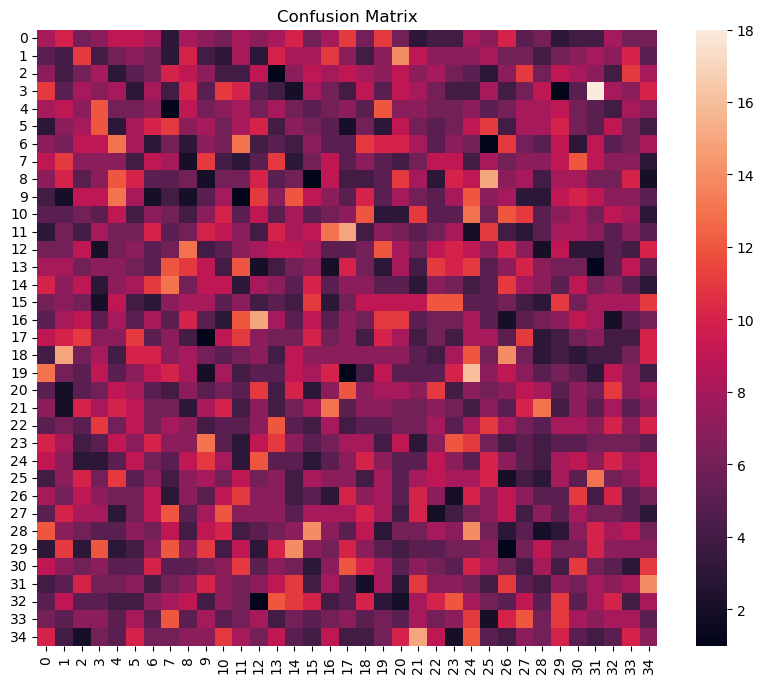

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(train_generator.class_indices.keys())
    )
)

              precision    recall  f1-score   support

           1       0.03      0.03      0.03       240
           2       0.02      0.02      0.02       240
           3       0.03      0.03      0.03       240
           4       0.03      0.03      0.03       240
           5       0.03      0.03      0.03       240
           6       0.03      0.03      0.03       240
           7       0.01      0.01      0.01       240
           8       0.03      0.03      0.03       240
           9       0.03      0.03      0.03       240
           A       0.02      0.02      0.02       240
           B       0.04      0.04      0.04       240
           C       0.03      0.03      0.03       240
           D       0.03      0.03      0.03       240
           E       0.02      0.02      0.02       240
           F       0.02      0.02      0.02       240
           G       0.05      0.05      0.05       240
           H       0.02      0.02      0.02       240
           I       0.03    

In [31]:
print(train_generator.class_indices)

{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'O': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}


In [32]:
from tensorflow.keras.models import load_model

model = load_model("sign_language_model.keras")

In [33]:
class_names = list(train_generator.class_indices.keys())

print(class_names)

['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [34]:
import tensorflow as tf

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

GPU Available: []


In [35]:
from tensorflow.keras.models import load_model

model = load_model("sign_language_model.h5")

In [39]:
class_names = [
    '1','2','3','4','5','6','7','8','9',
    'A','B','C','D','E','F','G','H','I','J',
    'K','L','M','N','O','P','Q','R','S','T',
    'U','V','W','X','Y','Z'
]

In [46]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open webcam")
    exit()

print("Press SPACE to capture image")
print("Press ESC to exit") 

Press SPACE to capture image
Press ESC to exit


In [51]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Sign Language Camera", frame)

    key = cv2.waitKey(1)

    # SPACE key
    if key == 32:

        cv2.imwrite("captured.jpg", frame)

        print("Image Captured")

        break

    # ESC key
    if key == 27:

        cap.release()
        cv2.destroyAllWindows()
        exit()

cap.release()
cv2.destroyAllWindows()

In [48]:
img = cv2.imread("captured.jpg")

img = cv2.resize(img,(64,64))


img = img.astype("float32")/255.0

img = np.expand_dims(img,axis=0)

In [49]:
prediction = model.predict(img,verbose=0)

predicted_index = np.argmax(prediction)

confidence = np.max(prediction)*100

print("Predicted Sign :",class_names[predicted_index])

print("Confidence :",round(confidence,2),"%")

Predicted Sign : R
Confidence : 50.1 %


In [50]:
img_display = cv2.imread("captured.jpg")

cv2.putText(
    img_display,
    f"{class_names[predicted_index]}",
    (20,50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0,255,0),
    2
)

cv2.imshow("Prediction",img_display)

cv2.waitKey(0)

cv2.destroyAllWindows()